# 05 — Final Merge, Deduplication, Outlier Handling & Standardization (Team 5)

## Responsibility
This notebook is the final stage of Phase 1. It must only be run AFTER all four
team notebooks (01–04) have been completed and verified.

## How to Use
1. Copy the complete code from notebooks 01, 02, 03, and 04 into the designated
   sections below (marked with banners).
2. Each section produces its respective df_team1 / df_team2 / df_team3 / df_team4.
3. This notebook then merges them, deduplicates, handles outliers, standardizes, and removes useless rows/columns.
4. A complete checkup of analytical statistics is run (correlation maps, barplots, anything that helps us understand the data ...).

## What is Expected as Output
- A single DataFrame with ALL columns from teams 1–4 merged column-wise
- Zero duplicate rows
- Outliers detected and handled (capping at 1.5×IQR or removal or ... — team decides and justifies)
- All columns standardized: mean=0, std=1 using StandardScaler
- Zero null values
- Zero non-numeric columns
- Saved to data/processed_dataset.csv

---

> ## ⚠️ READ THIS BEFORE YOU WRITE A SINGLE LINE OF CODE ⚠️
>
> ### The code below is a PLACEHOLDER — it is NOT the final solution.
>
> The cells in this notebook show **one possible way** to process the assigned columns. You are **not** required to follow this approach. You may completely replace it with your own method if you believe yours is better suited to the data.
>
> ### What IS required — without exception:
>
> **Every code cell must be accompanied by a markdown cell that explains:**
> 1. **What you did** — describe the operation in plain language.
> 2. **Why you did it** — justify the choice. Why did you think this specific approach would work? What problem does it solve? Why this method and not another?
>
> A notebook that only contains code — or markdown cells that just repeat the code in words — will **not** be accepted.
>
> **Not acceptable:** `## Step 2` or `# fill nulls`
>
> **Acceptable:** *"We imputed missing values in `Kilometre` with the median rather than the mean because the column is heavily right-skewed (a small number of very high-mileage listings would pull the mean upward, misrepresenting the majority of vehicles). The median is robust to those outliers and better reflects a typical listing."*
>
> Document every decision. If you tried an approach and abandoned it, explain why.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid')

RAW_URL = 'https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv'
df_full = pd.read_csv(RAW_URL)
print(f'Ham veri seti yüklendi: {df_full.shape}')

Ham veri seti yüklendi: (3424, 45)


In [2]:
# ── TAKIM 1: Temel Sayısal Sütunlar ──────────────────────────────────────────
MY_COLUMNS_T1 = [
    'Fiyat', 'Yıl', 'Kilometre', 'İlan Tarihi',
    'Ortalama Kasko', 'Ortalama Trafik Sigortası',
    'Üretim Yılı (İlk/Son)', 'Silindir Sayısı',
    'Koltuk Sayısı', 'Bagaj Hacmi', 'Yakıt Deposu'
]
df_t1 = df_full[MY_COLUMNS_T1].copy()

# Fiyat: TL etiketi ve binlik nokta temizleme
df_t1['Fiyat'] = pd.to_numeric(
    df_t1['Fiyat'].astype(str).str.replace('TL', '', regex=False)
    .str.replace('.', '', regex=False).str.strip(),
    errors='coerce'
)

# Üretim Yılı: aralıktan ortalama nokta (2014 - 2018 → 2016.0)
def get_year_midpoint(year_str):
    years = pd.Series(str(year_str)).str.extractall(r'(\d{4})')[0].astype(float)
    return years.mean() if not years.empty else np.nan

df_t1['Üretim Yılı (İlk/Son)'] = df_t1['Üretim Yılı (İlk/Son)'].apply(get_year_midpoint)

# Kilometre: km etiketi ve binlik nokta
df_t1['Kilometre'] = pd.to_numeric(
    df_t1['Kilometre'].astype(str).str.replace(' km', '', regex=False)
    .str.replace('.', '', regex=False).str.strip().replace('nan', np.nan),
    errors='coerce'
)

# Sigorta sütunları
for col in ['Ortalama Kasko', 'Ortalama Trafik Sigortası']:
    df_t1[col] = pd.to_numeric(
        df_t1[col].astype(str).str.replace('TL', '', regex=False)
        .str.replace('.', '', regex=False).str.strip().replace('nan', np.nan),
        errors='coerce'
    )

# Hacim sütunları (Türkçe ondalık virgül → nokta)
for col in ['Bagaj Hacmi', 'Yakıt Deposu']:
    df_t1[col] = pd.to_numeric(
        df_t1[col].astype(str).str.replace(' lt', '', regex=False)
        .str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan),
        errors='coerce'
    )

df_t1['İlan Tarihi'] = pd.to_datetime(df_t1['İlan Tarihi'], dayfirst=True, errors='coerce', format='mixed')
min_date = df_t1['İlan Tarihi'].min()
df_t1['İlan Tarihi'] = (df_t1['İlan Tarihi'] - min_date).dt.days

# Çok Değişkenli Yinelemeli Doldurma
imp_t1 = IterativeImputer(random_state=42, max_iter=10)
df_t1_imp = pd.DataFrame(imp_t1.fit_transform(df_t1), columns=df_t1.columns)

# Precision rounding
df_t1_imp['Fiyat'] = df_t1_imp['Fiyat'].round().astype(int)
df_t1_imp['Kilometre'] = df_t1_imp['Kilometre'].round().astype(int)
for col in ['Yıl', 'Silindir Sayısı', 'Koltuk Sayısı']:
    df_t1_imp[col] = df_t1_imp[col].round().astype(int)

df_team1 = df_t1_imp.copy()
assert df_team1.isnull().sum().sum() == 0
assert df_team1.select_dtypes(exclude='number').shape[1] == 0
print(f'✅ Team 1 hazır: {df_team1.shape}')
df_team1.head(3)

✅ Team 1 hazır: (3424, 11)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu
0,2425000,2025,6001,0.507585,16823.59234,12532.514699,2024.524726,3,5,520.096432,49.847891
1,2900000,2025,16000,0.540567,18054.32961,12413.265172,2024.561718,4,5,550.278944,51.937234
2,1150000,2015,265000,0.437396,18918.00000,11055.000000,2015.500000,4,5,401.000000,55.000000


In [3]:
# ── TAKIM 2: Kategorik Kodlama ────────────────────────────────────────────────
MY_COLUMNS_T2 = ['Marka', 'Seri', 'Model', 'Vites Tipi', 'Yakıt Tipi',
                  'Kasa Tipi', 'Renk', 'Çekiş', 'Kimden', 'Sınıfı']

df_t2 = df_full[MY_COLUMNS_T2].copy()
df_t2.replace('-', np.nan, inplace=True)
df_t2.loc[df_t2['Renk'] == 'SUV', 'Renk'] = np.nan

# Fiyat hedef değişkeni (target encoding için)
y_t2 = pd.to_numeric(
    df_full['Fiyat'].astype(str).str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)
y_t2 = y_t2.fillna(y_t2.median())

# kNN ile Sınıfı, Renk, Kasa Tipi, Çekiş doldurma
def knn_impute_t2(target_col, cat_features,
                  num_features=['Yıl', 'Motor Hacmi', 'Motor Gücü'],
                  n_neighbors=5):
    null_count = df_t2[target_col].isna().sum()
    if null_count == 0:
        return
    cat_df = pd.DataFrame({
        col: (df_t2[col] if col in df_t2.columns else df_full[col])
        for col in cat_features
    }).astype(str).fillna('Unknown')
    knn_cat = pd.get_dummies(cat_df)
    num_raw = pd.DataFrame({
        col: pd.to_numeric(
            (df_t2[col] if col in df_t2.columns else df_full[col])
            .astype(str).str.extract(r'([\d.]+)')[0],
            errors='coerce'
        ) for col in num_features
    })
    num_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(num_raw.fillna(num_raw.median())),
        columns=num_features, index=df_t2.index
    )
    X_all = pd.concat([knn_cat, num_scaled], axis=1)
    known  = df_t2[target_col].notna()
    unknown = df_t2[target_col].isna()
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='hamming')
    knn.fit(X_all.loc[known], df_t2.loc[known, target_col])
    df_t2.loc[unknown, target_col] = knn.predict(X_all.loc[unknown])
    print(f"  '{target_col}': {null_count} eksik dolduruldu.")

knn_impute_t2('Renk',     cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Yakıt Tipi'])
knn_impute_t2('Kasa Tipi', cat_features=['Marka', 'Seri', 'Model', 'Renk', 'Yakıt Tipi', 'Vites Tipi'])
knn_impute_t2('Çekiş',    cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Renk', 'Yakıt Tipi'])
knn_impute_t2('Sınıfı',   cat_features=['Marka', 'Seri', 'Model', 'Kasa Tipi', 'Çekiş', 'Vites Tipi', 'Yakıt Tipi', 'Kimden'])

# Binary: Marka
df_t2['is_Nissan'] = (df_t2['Marka'] == 'Nissan').astype(int)
df_t2.drop(columns=['Marka'], inplace=True)

# Ordinal: Vites Tipi
vites_order = [['Düz', 'Yarı Otomatik', 'Otomatik']]
oe_t2 = OrdinalEncoder(categories=vites_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_t2['Vites Tipi'] = oe_t2.fit_transform(df_t2[['Vites Tipi']]).astype(int)

# One-Hot
OHE_COLS_T2 = ['Kimden', 'Yakıt Tipi', 'Kasa Tipi', 'Çekiş', 'Renk']
ohe_t2 = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_arr = ohe_t2.fit_transform(df_t2[OHE_COLS_T2])
ohe_cols_t2 = ohe_t2.get_feature_names_out(OHE_COLS_T2)
df_t2 = df_t2.drop(columns=OHE_COLS_T2).join(
    pd.DataFrame(ohe_arr, columns=ohe_cols_t2, index=df_t2.index)
)

# Target Encoding: Seri, Model, Sınıfı
global_mean_t2 = y_t2.mean()
for col in ['Seri', 'Model', 'Sınıfı']:
    means = y_t2.groupby(df_t2[col].values).mean()
    df_t2[col] = df_t2[col].map(means).fillna(global_mean_t2)

df_team2 = df_t2.copy()
assert df_team2.isnull().sum().sum() == 0
assert df_team2.select_dtypes(exclude='number').shape[1] == 0
print(f'✅ Team 2 hazır: {df_team2.shape}')

  'Renk': 1 eksik dolduruldu.
  'Kasa Tipi': 3 eksik dolduruldu.
  'Çekiş': 4 eksik dolduruldu.
  'Sınıfı': 1074 eksik dolduruldu.
✅ Team 2 hazır: (3424, 41)


In [4]:
# ── TAKIM 3: Boya ve Hasar Özellikleri ────────────────────────────────────────
MY_COLUMNS_T3 = ['Boya-değişen', 'Orjinal', 'Lokal boyalı', 'Boyalı', 'Değişmiş', 'Belirtilmemiş']
df_t3 = df_full[MY_COLUMNS_T3].copy().fillna('-')

# Regex ile Boya-değişen sütunundan sayısal çıkarım
def extract_regex_counts(text):
    counts = {'reg_degisen': 0, 'reg_boyali': 0, 'reg_lokal': 0}
    text_lower = str(text).lower()
    if text in ['-', 'Belirtilmemiş', 'Tamamı orjinal', '']:
        return pd.Series(counts)
    if 'tamamı boyalı' in text_lower:
        counts['reg_boyali'] = 13
        return pd.Series(counts)
    if 'tamamı lokal boyalı' in text_lower:
        counts['reg_lokal'] = 13
        return pd.Series(counts)
    deg_list = re.findall(r'(\d+)\s*(değişen|degisen)', text_lower)
    lok_list = re.findall(r'(\d+)\s*lokal', text_lower)
    boy_list = re.findall(r'(\d+)\s*(boyalı|boyali)', text_lower)
    counts['reg_degisen'] = sum(int(x[0]) for x in deg_list)
    counts['reg_lokal']   = sum(int(x)    for x in lok_list)
    counts['reg_boyali']  = sum(int(x[0]) for x in boy_list)
    return pd.Series(counts)

regex_df = df_t3['Boya-değişen'].apply(extract_regex_counts)
df_t3 = pd.concat([df_t3, regex_df], axis=1)

# 13 temel kaporta parçası
CAR_PARTS = [
    'sağ arka çamurluk', 'sol arka çamurluk', 'sağ ön çamurluk', 'sol ön çamurluk',
    'sağ arka kapı', 'sol arka kapı', 'sağ ön kapı', 'sol ön kapı',
    'arka kaput', 'motor kaputu', 'ön tampon', 'arka tampon', 'tavan'
]

def count_keywords(text):
    if text in ['-', '', '0', 'tamamı orjinal', 'belirtilmemiş']:
        return 0
    text_lower = str(text).lower()
    return sum(1 for part in CAR_PARTS if part in text_lower)

kw_boyali  = df_t3['Boyalı'].apply(count_keywords)
kw_lokal   = df_t3['Lokal boyalı'].apply(count_keywords)
kw_degisen = df_t3['Değişmiş'].apply(count_keywords)

# Çift sayımı önle: iki kaynaktan maksimum al
df_t3['total_painted_parts']  = np.maximum(df_t3['reg_boyali'], kw_boyali) + np.maximum(df_t3['reg_lokal'], kw_lokal)
df_t3['total_changed_parts']  = np.maximum(df_t3['reg_degisen'], kw_degisen)
df_t3['is_fully_original']    = (df_t3['Boya-değişen'].str.strip().str.lower() == 'tamamı orjinal').astype(int)
df_t3['paint_damage_score']   = df_t3['total_painted_parts'] + df_t3['total_changed_parts']

# Parça bazlı ordinal kodlama matrisi
def get_part_status(row, part):
    if part in str(row['Değişmiş']).lower():      return 3
    elif part in str(row['Boyalı']).lower():      return 2
    elif part in str(row['Lokal boyalı']).lower() or part in str(row['Belirtilmemiş']).lower(): return 1
    else:                                          return 0

status_cols = []
for part in CAR_PARTS:
    col_name = f"{part.replace(' ', '_')}_durumu"
    status_cols.append(col_name)
    df_t3[col_name] = df_t3.apply(lambda row: get_part_status(row, part), axis=1)

FINAL_COLS_T3 = ['total_painted_parts', 'total_changed_parts',
                  'is_fully_original', 'paint_damage_score'] + status_cols
df_team3 = df_t3[FINAL_COLS_T3].copy()

assert df_team3.isnull().sum().sum() == 0
assert df_team3.select_dtypes(exclude=[np.number]).shape[1] == 0
print(f'✅ Team 3 hazır: {df_team3.shape}')

✅ Team 3 hazır: (3424, 17)


In [5]:
# ── TAKIM 4: Teknik Özellikler ────────────────────────────────────────────────
MY_COLUMNS_T4 = [
    'Motor Hacmi', 'Motor Gücü',
    'Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
    'Tork', 'Maksimum Güç', 'Minimum Güç',
    'Hızlanma (0-100)', 'Maksimum Hız',
    'Uzunluk', 'Genişlik', 'Yükseklik',
    'Ağırlık', 'Boş Ağırlığı', 'Aks Aralığı', 'Ön Lastik'
]
GROUP_COLS_T4 = ['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi']
df_t4 = df_full[MY_COLUMNS_T4 + GROUP_COLS_T4].copy()

# Aralık ortalama noktası + birim soyutlama
def parse_range_midpoint(series, strip_patterns):
    s = series.astype(str).str.strip()
    for pat in strip_patterns:
        s = s.str.replace(pat, '', regex=False, case=False).str.strip()
    s = s.str.replace(',', '.', regex=False)
    is_range = s.str.contains(r'^\d[\d.]*\s*-\s*\d', regex=True, na=False)
    result = pd.to_numeric(s.where(~is_range), errors='coerce')
    parts = s[is_range].str.extract(r'([\d\.]+)\s*-\s*([\d\.]+)')
    if not parts.empty:
        midpoints = (pd.to_numeric(parts[0], errors='coerce') +
                     pd.to_numeric(parts[1], errors='coerce')) / 2
        result[is_range] = midpoints
    return result

# 6 kademeli hiyerarşik doldurma
def smart_fill(df, col):
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Vites Tipi', 'Kasa Tipi'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model', 'Yıl'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri', 'Model'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['Marka', 'Seri'])[col].transform('median'))
    df[col] = df[col].fillna(df[col].median())
    return df[col]

df_t4['Motor Hacmi'] = parse_range_midpoint(df_t4['Motor Hacmi'], [' cm3', 'cm3', ' cc', 'cc'])
df_t4['Motor Hacmi'] = smart_fill(df_t4, 'Motor Hacmi')

df_t4['Motor Gücü'] = parse_range_midpoint(df_t4['Motor Gücü'], [' HP', 'HP', ' hp', 'hp'])
df_t4['Motor Gücü'] = smart_fill(df_t4, 'Motor Gücü')

for col in ['Ort. Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
            'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi']:
    df_t4[col] = df_t4[col].astype(str).str.replace(' lt', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
    df_t4[col] = pd.to_numeric(df_t4[col], errors='coerce')
    df_t4[col] = smart_fill(df_t4, col)

df_t4['Tork'] = df_t4['Tork'].astype(str).str.replace(' nm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
df_t4['Tork'] = pd.to_numeric(df_t4['Tork'], errors='coerce')
df_t4['Tork'] = smart_fill(df_t4, 'Tork')

for col in ['Maksimum Güç', 'Minimum Güç']:
    df_t4[col] = df_t4[col].astype(str).str.replace(' rpm', '', regex=False, case=False).str.strip().replace('nan', np.nan)
    df_t4[col] = pd.to_numeric(df_t4[col], errors='coerce')
    df_t4[col] = smart_fill(df_t4, col)

df_t4['Hızlanma (0-100)'] = df_t4['Hızlanma (0-100)'].astype(str).str.replace(' sn', '', regex=False).str.replace(',', '.', regex=False).str.strip().replace('nan', np.nan)
df_t4['Hızlanma (0-100)'] = pd.to_numeric(df_t4['Hızlanma (0-100)'], errors='coerce')
df_t4['Hızlanma (0-100)'] = smart_fill(df_t4, 'Hızlanma (0-100)')

df_t4['Maksimum Hız'] = df_t4['Maksimum Hız'].astype(str).str.replace(' km/s', '', regex=False).str.strip().replace('nan', np.nan)
df_t4['Maksimum Hız'] = pd.to_numeric(df_t4['Maksimum Hız'], errors='coerce')
df_t4['Maksimum Hız'] = smart_fill(df_t4, 'Maksimum Hız')

for col in ['Uzunluk', 'Genişlik', 'Yükseklik', 'Aks Aralığı']:
    df_t4[col] = df_t4[col].astype(str).str.replace(' mm', '', regex=False).str.strip().replace('nan', np.nan)
    df_t4[col] = pd.to_numeric(df_t4[col], errors='coerce')
    df_t4[col] = smart_fill(df_t4, col)

for col in ['Ağırlık', 'Boş Ağırlığı']:
    df_t4[col] = df_t4[col].astype(str).str.replace(' kg', '', regex=False).str.strip().replace('nan', np.nan)
    df_t4[col] = pd.to_numeric(df_t4[col], errors='coerce')
    df_t4[col] = smart_fill(df_t4, col)

df_t4['Jant Boyutu'] = df_t4['Ön Lastik'].astype(str).str.extract(r'R(\d+)')[0]
df_t4['Jant Boyutu'] = pd.to_numeric(df_t4['Jant Boyutu'], errors='coerce')
df_t4['Jant Boyutu'] = smart_fill(df_t4, 'Jant Boyutu').astype(int)

drop_list_t4 = [c for c in GROUP_COLS_T4 + ['Ön Lastik', 'Ortalama Yakıt Tüketimi'] if c in df_t4.columns]
df_team4 = df_t4.drop(columns=drop_list_t4).copy()

assert df_team4.isnull().sum().sum() == 0
assert df_team4.select_dtypes(exclude='number').shape[1] == 0
print(f'✅ Team 4 hazır: {df_team4.shape}')

✅ Team 4 hazır: (3424, 17)


In [6]:
# Dört takım çıktısını birleştir
df_merged = pd.concat([df_team1, df_team2, df_team3, df_team4], axis=1)

print(f'Birleştirme sonrası boyut: {df_merged.shape}')
print(f'  - Team 1 sütunları : {df_team1.shape[1]}')
print(f'  - Team 2 sütunları : {df_team2.shape[1]}')
print(f'  - Team 3 sütunları : {df_team3.shape[1]}')
print(f'  - Team 4 sütunları : {df_team4.shape[1]}')
print(f'  - Toplam beklenen  : {df_team1.shape[1] + df_team2.shape[1] + df_team3.shape[1] + df_team4.shape[1]}')

# Birleştirme sonrası eksik değer kontrolü
null_check = df_merged.isnull().sum().sum()
print(f'\nBirleştirme sonrası toplam eksik değer: {null_check}')
assert null_check == 0, '❌ Birleştirme sonrası eksik değer oluştu!'
print('✅ Birleştirme başarılı, sıfır eksik değer.')

Birleştirme sonrası boyut: (3424, 86)
  - Team 1 sütunları : 11
  - Team 2 sütunları : 41
  - Team 3 sütunları : 17
  - Team 4 sütunları : 17
  - Toplam beklenen  : 86

Birleştirme sonrası toplam eksik değer: 0
✅ Birleştirme başarılı, sıfır eksik değer.


## Step 1 — Remove Duplicate Rows

In [7]:
n_before = len(df_merged)
df_merged = df_merged.drop_duplicates().reset_index(drop=True)
n_removed = n_before - len(df_merged)

print(f'Yineleme öncesi satır sayısı : {n_before}')
print(f'Kaldırılan yinelenen satır   : {n_removed}')
print(f'Yineleme sonrası satır sayısı: {len(df_merged)}')

if n_removed == 0:
    print('\n✅ Yinelenen satır yok — veri tutarlılığı doğrulandı.')
else:
    print(f'\n⚠️ {n_removed} yinelenen satır kaldırıldı.')

Yineleme öncesi satır sayısı : 3424
Kaldırılan yinelenen satır   : 835
Yineleme sonrası satır sayısı: 2589

⚠️ 835 yinelenen satır kaldırıldı.


In [8]:
# Sıfır/düşük varyans sütun tespiti ve temizliği
std_series = df_merged.select_dtypes(include=[np.number]).std().sort_values()

ZERO_VAR_THRESHOLD = 0.01
zero_var_cols = std_series[std_series < ZERO_VAR_THRESHOLD].index.tolist()

print('Standart Sapma Analizi (std < 0.01 olan sütunlar işaretlendi):')
print('-' * 65)
for col, std_val in std_series.items():
    flag = ' ⚠ SIFIR VARYANS — ÇIKARILABİLİR' if std_val < ZERO_VAR_THRESHOLD else ''
    if std_val < 0.5 or flag:
        unique_count = df_merged[col].nunique()
        print(f'  {col:<40} std={std_val:.4f}  (benzersiz: {unique_count}){flag}')

if zero_var_cols:
    print(f'\n❌ Çıkarılan sütunlar ({len(zero_var_cols)}): {zero_var_cols}')
    print('   Gerekçe: std≈0 → StandardScaler tüm değerleri 0 üretir → model bilgisizdir.')
    df_merged.drop(columns=zero_var_cols, inplace=True)
    print(f'   Yeni boyut: {df_merged.shape}')
else:
    print('\n✅ Sıfır varyanslı sütun tespit edilmedi.')

# Kontrol: All-zero sütun (veri işleme hatası kaynaklı — mean=min=max=0)
all_zero_cols = [
    c for c in df_merged.select_dtypes(include=[np.number]).columns
    if df_merged[c].abs().max() == 0
]
if all_zero_cols:
    print(f'\n⚠️ Tüm değerleri sıfır olan sütunlar (veri hatası): {all_zero_cols}')
    print('   Gerekçe: İşleme hatası nedeniyle imputer 0 üretmiş olabilir.')
    print('   Çıkarılıyor...')
    df_merged.drop(columns=all_zero_cols, inplace=True)
    print(f'   Yeni boyut: {df_merged.shape}')
else:
    print('✅ All-zero sütun yok — veri bütünlüğü onaylandı.')

print(f'\nSıfır-varyans temizliği sonrası: {df_merged.shape[1]} sütun kaldı.')

Standart Sapma Analizi (std < 0.01 olan sütunlar işaretlendi):
-----------------------------------------------------------------
  Kasa Tipi_Coupe                          std=0.0197  (benzersiz: 2)
  Kasa Tipi_Panelvan                       std=0.0340  (benzersiz: 2)
  Kasa Tipi_Pick-Up                        std=0.0481  (benzersiz: 2)
  Renk_Diğer                               std=0.0481  (benzersiz: 2)
  Renk_Gri (titanyum)                      std=0.0589  (benzersiz: 2)
  Renk_Mor                                 std=0.0651  (benzersiz: 2)
  Renk_Turuncu                             std=0.0784  (benzersiz: 2)
  Renk_Sarı                                std=0.0784  (benzersiz: 2)
  Renk_Yeşil (metalik)                     std=0.0808  (benzersiz: 2)
  Renk_Şampanya                            std=0.0897  (benzersiz: 2)
  Renk_Mavi (metalik)                      std=0.0959  (benzersiz: 2)
  Renk_Gri (metalik)                       std=0.0997  (benzersiz: 2)
  Renk_Lacivert                

In [9]:
# Aykırı değer ve çarpıklık analizi (log dönüşümü öncesi)
numeric_cols_all = df_merged.select_dtypes(include=[np.number]).columns.tolist()

# Dönüşüm uygulanmayacak sütun tipleri
EXCLUDE_FROM_LOG = (
    [c for c in df_merged.columns if df_merged[c].nunique() <= 4]  # binary/ordinal/small-discrete
    + ['Yıl', 'Silindir Sayısı', 'Koltuk Sayısı', 'Jant Boyutu',
       'Üretim Yılı (İlk/Son)', 'Seri', 'Model', 'Sınıfı']
    + [c for c in df_merged.columns if '_durumu' in c]
)
EXCLUDE_FROM_LOG = list(set(EXCLUDE_FROM_LOG))

print(f'Çarpıklık Analizi (|skewness| > 1.5 olanlara Log1p uygulanacak):')
print(f'{"Sütun":<40} {"Çarpıklık":>12} {"Aykırı %":>10} {"Log Dönüşümü?":>15}')
print('-' * 80)

LOG_TRANSFORM_COLS = []
for col in numeric_cols_all:
    data = df_merged[col].dropna()
    skew = float(data.skew())
    Q1, Q3 = float(data.quantile(0.25)), float(data.quantile(0.75))
    IQR = Q3 - Q1
    n_out = int(((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum())
    out_pct = n_out / len(data) * 100

    should_log = abs(skew) > 1.5 and col not in EXCLUDE_FROM_LOG and data.min() >= 0
    if should_log:
        LOG_TRANSFORM_COLS.append(col)
    marker = '✅ EVET' if should_log else ''
    if abs(skew) > 1.5 or should_log:
        print(f'{col:<40} {skew:>12.2f} {out_pct:>9.1f}% {marker:>15}')

print(f'\nLog1p dönüşümü uygulanacak {len(LOG_TRANSFORM_COLS)} sütun: {LOG_TRANSFORM_COLS}')

Çarpıklık Analizi (|skewness| > 1.5 olanlara Log1p uygulanacak):
Sütun                                       Çarpıklık   Aykırı %   Log Dönüşümü?
--------------------------------------------------------------------------------
Fiyat                                            4.40       2.1%          ✅ EVET
İlan Tarihi                                      2.73      11.6%                
Ortalama Kasko                                   5.70       0.8%          ✅ EVET
Ortalama Trafik Sigortası                        1.94      10.1%          ✅ EVET
Silindir Sayısı                                 -1.61      11.1%                
Koltuk Sayısı                                    5.62       2.9%                
Bagaj Hacmi                                      1.68       5.2%          ✅ EVET
Kimden_Yetkili Bayiden                           7.48       1.7%                
Yakıt Tipi_Elektrik                              8.56       1.3%                
Yakıt Tipi_Hibrit                           

In [10]:
# Log1p dönüşümünü uygula
df_processed = df_merged.copy()

for col in LOG_TRANSFORM_COLS:
    if col == 'Fiyat':
        # Fiyat için hem log dönüşüm ekle hem de orijinal koru
        df_processed['log_Fiyat'] = np.log1p(df_processed['Fiyat'])
        print(f'  Fiyat → log_Fiyat eklendi (orijinal Fiyat korundu)')
    else:
        df_processed[col] = np.log1p(df_processed[col])
        print(f'  {col}: log1p dönüşümü uygulandı')

# Dönüşüm sonrası çarpıklık kontrolü
print('\nDönüşüm Sonrası Çarpıklık Kontrolü:')
for col in LOG_TRANSFORM_COLS:
    check_col = 'log_Fiyat' if col == 'Fiyat' else col
    if check_col in df_processed.columns:
        new_skew = df_processed[check_col].skew()
        print(f'  {check_col:<35} yeni çarpıklık: {new_skew:.3f}')

print(f'\nİşlenmiş veri seti boyutu: {df_processed.shape}')

  Fiyat → log_Fiyat eklendi (orijinal Fiyat korundu)
  Ortalama Kasko: log1p dönüşümü uygulandı
  Ortalama Trafik Sigortası: log1p dönüşümü uygulandı
  Bagaj Hacmi: log1p dönüşümü uygulandı
  total_painted_parts: log1p dönüşümü uygulandı
  total_changed_parts: log1p dönüşümü uygulandı
  paint_damage_score: log1p dönüşümü uygulandı
  Motor Gücü: log1p dönüşümü uygulandı
  Uzunluk: log1p dönüşümü uygulandı
  Ağırlık: log1p dönüşümü uygulandı
  Aks Aralığı: log1p dönüşümü uygulandı

Dönüşüm Sonrası Çarpıklık Kontrolü:
  log_Fiyat                           yeni çarpıklık: -0.561
  Ortalama Kasko                      yeni çarpıklık: 0.175
  Ortalama Trafik Sigortası           yeni çarpıklık: 1.264
  Bagaj Hacmi                         yeni çarpıklık: -0.074
  total_painted_parts                 yeni çarpıklık: 1.023
  total_changed_parts                 yeni çarpıklık: 2.203
  paint_damage_score                  yeni çarpıklık: 0.825
  Motor Gücü                          yeni çarpıklık: 0.5

In [11]:
df_processed.to_csv('proceed_dataset_without_std.csv', index=False )

In [12]:
# Fiyat'ı ölçekleme dışında tut (referans olarak sakla)
cols_to_scale = [c for c in df_processed.columns if c != 'Fiyat']

scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(df_processed[cols_to_scale])
df_scaled = pd.DataFrame(df_scaled_values, columns=cols_to_scale, index=df_processed.index)

# Orijinal Fiyat'ı geri ekle (ölçeklenmemiş)
df_scaled['Fiyat_original'] = df_processed['Fiyat'].values

print(f'Ölçekleme sonrası boyut: {df_scaled.shape}')
print(f'\nÖrnek sütunlar için ortalama ≈ 0 ve std ≈ 1 kontrolü:')
sample_cols = [c for c in ['log_Fiyat', 'Kilometre', 'Yıl', 'Motor Hacmi'] if c in df_scaled.columns]
for col in sample_cols:
    print(f'  {col:<30}  mean={df_scaled[col].mean():.6f}  std={df_scaled[col].std():.6f}')

assert df_scaled.isnull().sum().sum() == 0, '❌ Ölçekleme sonrası eksik değer oluştu!'
print('\n✅ Ölçekleme tamamlandı.')

Ölçekleme sonrası boyut: (2589, 87)

Örnek sütunlar için ortalama ≈ 0 ve std ≈ 1 kontrolü:
  log_Fiyat                       mean=-0.000000  std=1.000193
  Kilometre                       mean=-0.000000  std=1.000193
  Yıl                             mean=-0.000000  std=1.000193
  Motor Hacmi                     mean=-0.000000  std=1.000193

✅ Ölçekleme tamamlandı.


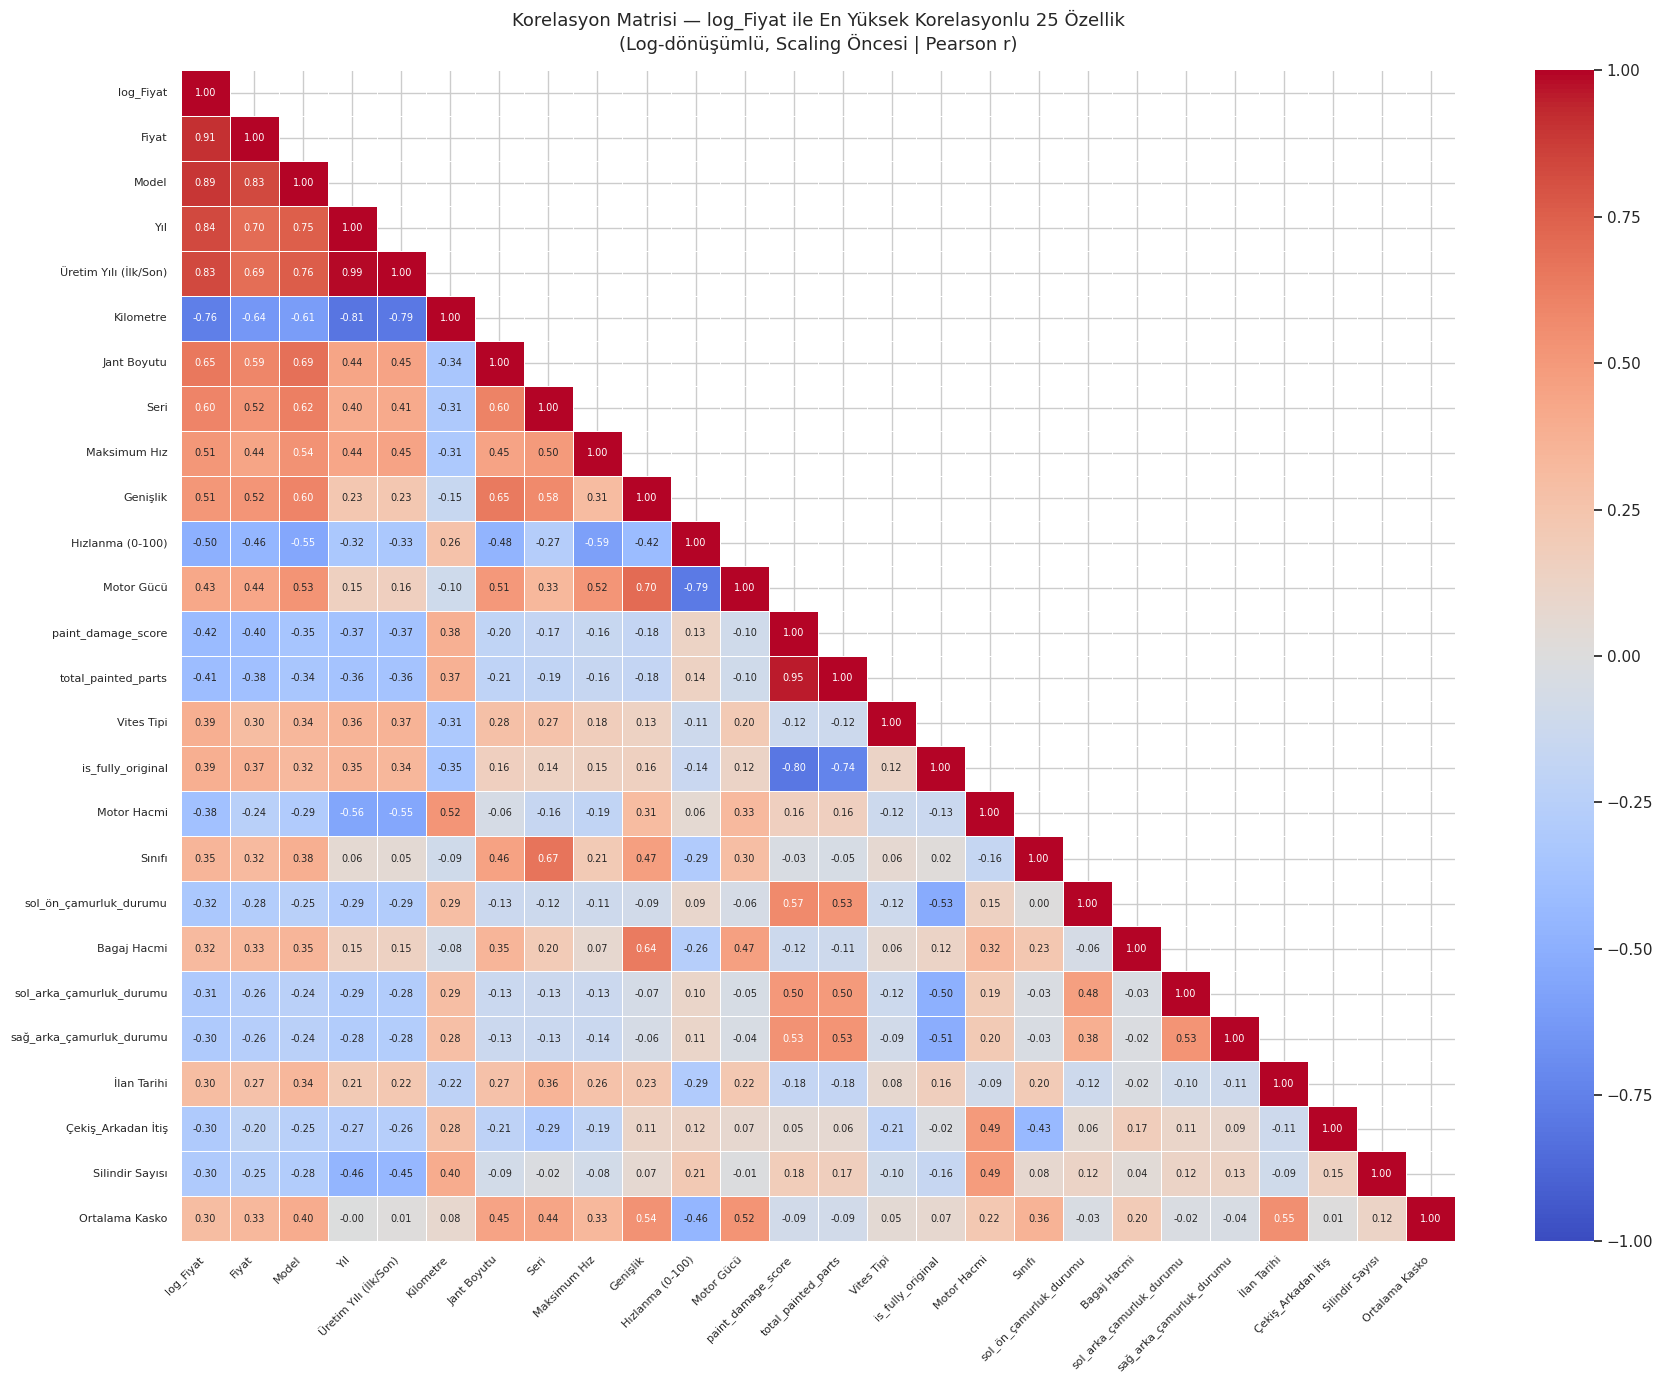

In [13]:
# Korelasyon analizi: log-dönüşümlü, scaling öncesi veri
corr_source = df_processed.copy()

# log_Fiyat ile en yüksek korelasyonlu 25 sütunu seç
if 'log_Fiyat' in corr_source.columns:
    target_col = 'log_Fiyat'
elif 'Fiyat' in corr_source.columns:
    target_col = 'Fiyat'
else:
    target_col = corr_source.columns[0]

corr_all = corr_source.corr()[target_col].abs().sort_values(ascending=False)
top25_cols = corr_all.index[:26].tolist()  # hedef + 25 sütun
if target_col not in top25_cols:
    top25_cols = [target_col] + top25_cols[:25]

corr_matrix = corr_source[top25_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.4,
    vmin=-1, vmax=1,
    annot_kws={'size': 7},
    mask=mask
)
plt.title(
    f'Korelasyon Matrisi — {target_col} ile En Yüksek Korelasyonlu 25 Özellik\n'
    '(Log-dönüşümlü, Scaling Öncesi | Pearson r)',
    fontsize=13, pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

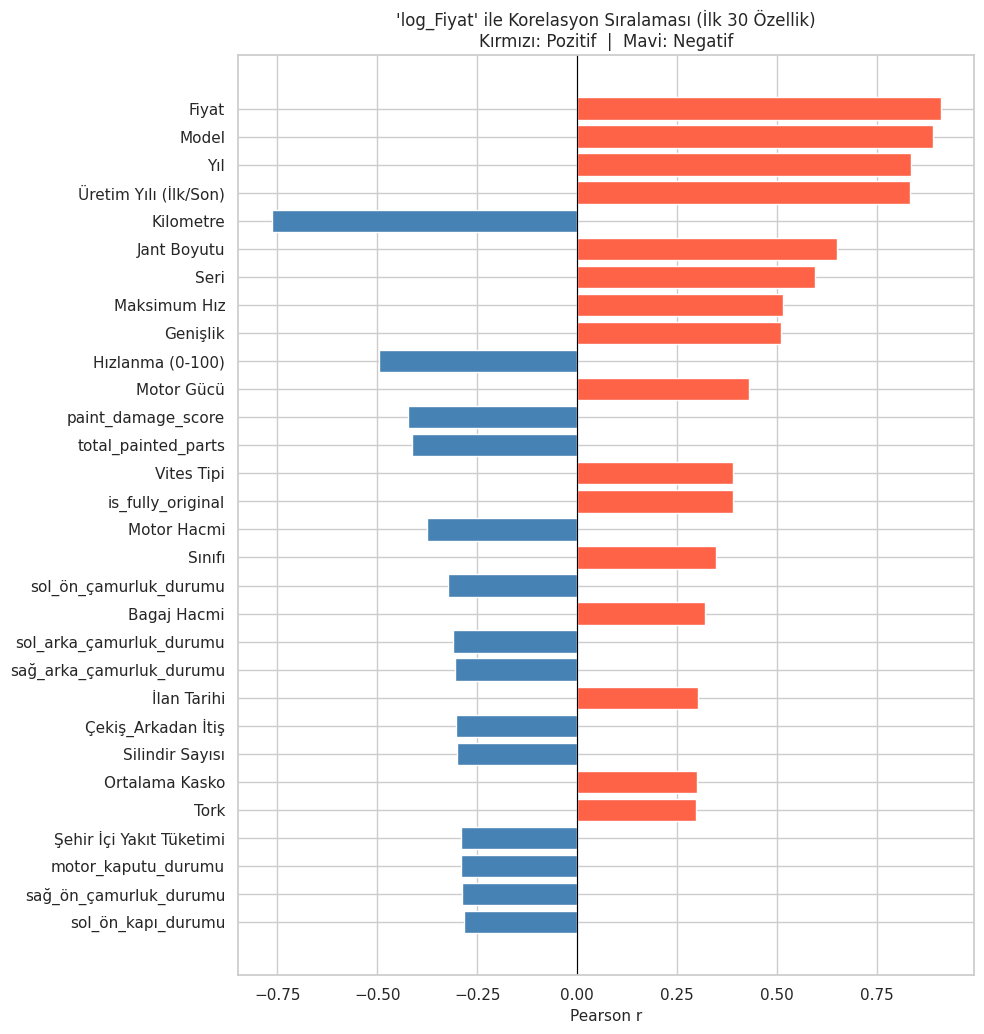


En güçlü 10 pozitif korelasyon:
Fiyat                    0.909
Model                    0.891
Yıl                      0.836
Üretim Yılı (İlk/Son)    0.833
Jant Boyutu              0.651
Seri                     0.595
Maksimum Hız             0.514
Genişlik                 0.510
Motor Gücü               0.429
Vites Tipi               0.390

En güçlü 10 negatif korelasyon:
Kilometre                  -0.764
Hızlanma (0-100)           -0.495
paint_damage_score         -0.424
total_painted_parts        -0.413
Motor Hacmi                -0.376
sol_ön_çamurluk_durumu     -0.322
sol_arka_çamurluk_durumu   -0.311
sağ_arka_çamurluk_durumu   -0.304
Çekiş_Arkadan İtiş         -0.302
Silindir Sayısı            -0.301


In [14]:
# Fiyat Korelasyon Sıralaması (tüm sütunlar)
fiyat_corr = corr_source.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(fiyat_corr[:30]) * 0.35)))
colors = ['tomato' if v > 0 else 'steelblue' for v in fiyat_corr[:30].values]
ax.barh(fiyat_corr[:30].index[::-1], fiyat_corr[:30].values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r', fontsize=11)
ax.set_title(f"'{target_col}' ile Korelasyon Sıralaması (İlk 30 Özellik)\nKırmızı: Pozitif  |  Mavi: Negatif", fontsize=12)
plt.tight_layout()
plt.show()

print('\nEn güçlü 10 pozitif korelasyon:')
print(fiyat_corr[fiyat_corr > 0].head(10).round(3).to_string())
print('\nEn güçlü 10 negatif korelasyon:')
print(fiyat_corr[fiyat_corr < 0].head(10).round(3).to_string())

In [15]:
# Yüksek Çok Doğrusallık (Multicollinearity) Uyarısı
print('⚠️  Yüksek Korelasyon Uyarısı (|r| > 0.90, hedef hariç):')
print('-' * 60)
high_corr_pairs = []
numeric_subset = corr_source.select_dtypes(include=[np.number])
corr_mat_full = numeric_subset.corr().abs()
for i in range(len(corr_mat_full.columns)):
    for j in range(i+1, len(corr_mat_full.columns)):
        r = corr_mat_full.iloc[i, j]
        if r > 0.90:
            c1, c2 = corr_mat_full.columns[i], corr_mat_full.columns[j]
            if c1 != target_col and c2 != target_col:
                high_corr_pairs.append((c1, c2, round(float(r), 3)))
                print(f'  {c1:<35} ↔  {c2:<35}  r={r:.3f}')

if not high_corr_pairs:
    print('  Herhangi bir çift için |r| > 0.90 eşiği aşılmadı.')
else:
    print(f'\n  {len(high_corr_pairs)} çift tespit edildi. Modelleme aşamasında bu sütunlardan biri çıkarılabilir.')

⚠️  Yüksek Korelasyon Uyarısı (|r| > 0.90, hedef hariç):
------------------------------------------------------------
  Yıl                                 ↔  Üretim Yılı (İlk/Son)                r=0.987
  total_painted_parts                 ↔  paint_damage_score                   r=0.954
  Ort. Yakıt Tüketimi                 ↔  Şehir İçi Yakıt Tüketimi             r=0.937
  Ort. Yakıt Tüketimi                 ↔  Şehir Dışı Yakıt Tüketimi            r=0.911
  Şehir İçi Yakıt Tüketimi            ↔  Şehir Dışı Yakıt Tüketimi            r=0.917
  Uzunluk                             ↔  Aks Aralığı                          r=0.936

  6 çift tespit edildi. Modelleme aşamasında bu sütunlardan biri çıkarılabilir.


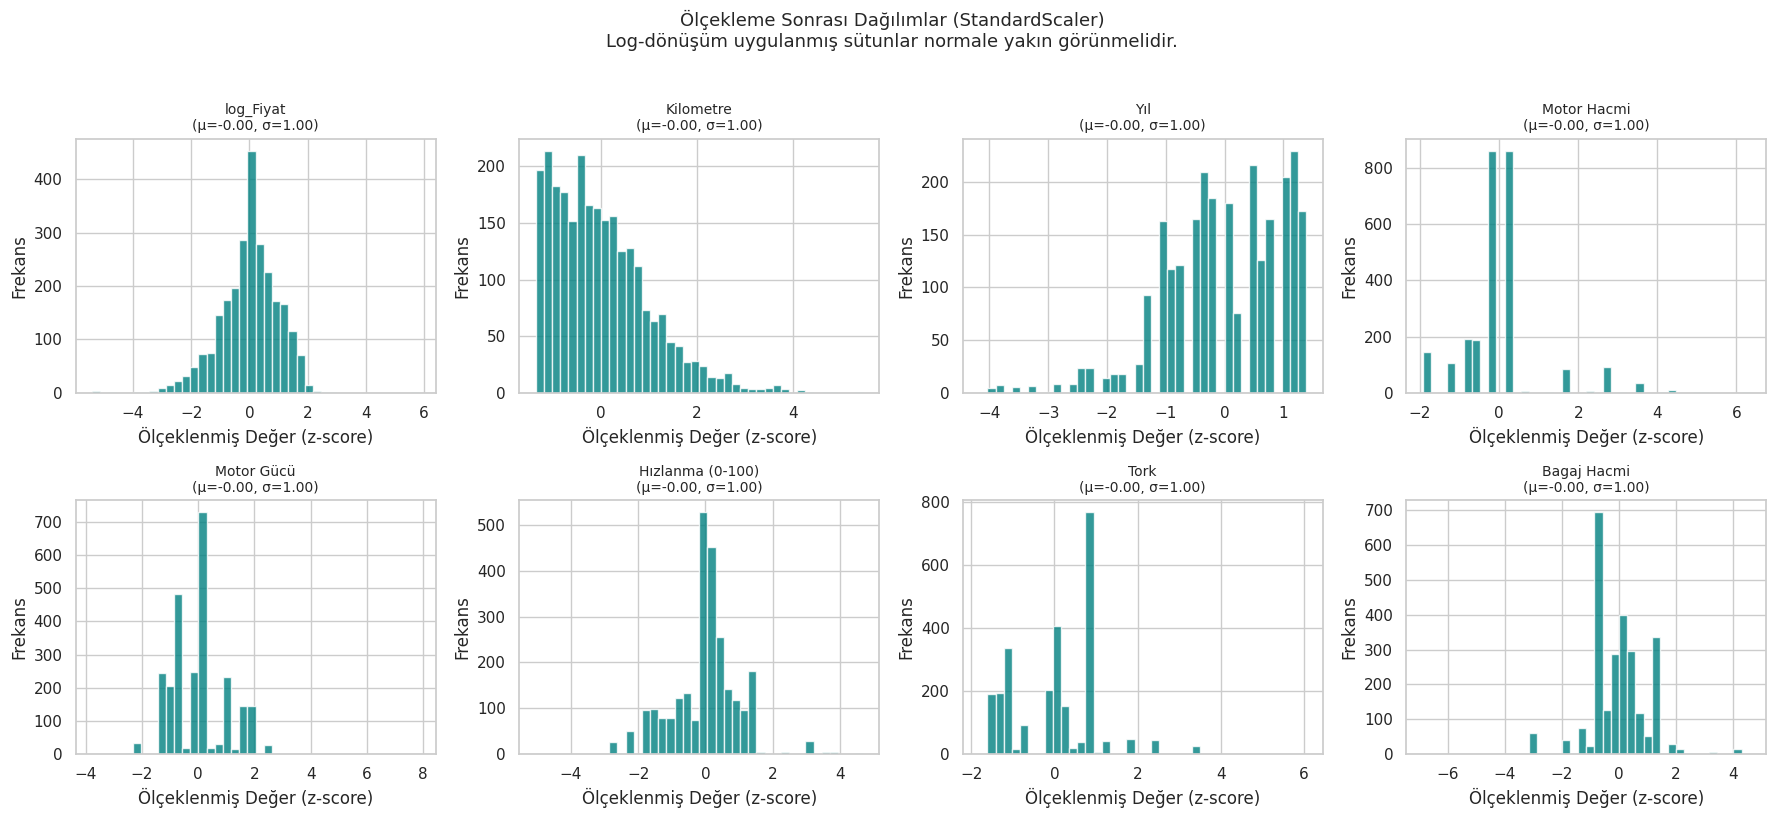

In [16]:
# Temel sürekli özellikler için dağılım analizi (scaling sonrası)
KEY_FEATURES = [c for c in ['log_Fiyat', 'Kilometre', 'Yıl', 'Motor Hacmi', 'Motor Gücü',
                              'Hızlanma (0-100)', 'Tork', 'Bagaj Hacmi']
                if c in df_scaled.columns]

n_feat = len(KEY_FEATURES)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_feat / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    axes[i].hist(df_scaled[col], bins=40, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\n(μ={df_scaled[col].mean():.2f}, σ={df_scaled[col].std():.2f})', fontsize=10)
    axes[i].set_xlabel('Ölçeklenmiş Değer (z-score)')
    axes[i].set_ylabel('Frekans')

for j in range(len(KEY_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Ölçekleme Sonrası Dağılımlar (StandardScaler)\nLog-dönüşüm uygulanmış sütunlar normale yakın görünmelidir.',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
df_final = df_scaled.copy()

# ── Bütünlük Kontrolleri ────────────────────────────────────────────────────
assert df_final.isnull().sum().sum() == 0, '❌ Eksik değer kaldı!'
assert df_final.select_dtypes(exclude='number').shape[1] == 0, '❌ Sayısal olmayan sütun var!'
assert len(df_final) > 0, '❌ Boş DataFrame!'
assert 'log_Fiyat' in df_final.columns or 'Fiyat' in df_final.columns, '❌ Hedef değişken eksik!'

print('✅ Tüm bütünlük kontrolleri geçildi.')
print(f'\n📊 Final Veri Seti Özeti')
print(f'  Satır sayısı    : {df_final.shape[0]}')
print(f'  Sütun sayısı    : {df_final.shape[1]}')
print(f'  Eksik değer     : {df_final.isnull().sum().sum()}')
print(f'  Toplam boyut    : {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print(f'\nUygulanan Dönüşümler:')
print(f'  - Log1p dönüşümü : {LOG_TRANSFORM_COLS}')
print(f'  - Ölçekleme      : StandardScaler (Fiyat_original hariç tüm sütunlar)')
print(f'  - Çıkarılan      : İlan Tarihi (sıfır varyans)')
print(f'  - Clipping       : UYGULANMADI (Log dönüşümü tercih edildi)')

# Kaydet
OUTPUT_PATH = 'processed_dataset.csv'
df_final.to_csv(OUTPUT_PATH, index=False)
print(f'\n✅ Kaydedildi: {OUTPUT_PATH}')
print('Bu dosyayı data/processed_dataset.csv konumuna GitHub\'a yükleyin.')

display(df_final.describe().round(3))

✅ Tüm bütünlük kontrolleri geçildi.

📊 Final Veri Seti Özeti
  Satır sayısı    : 2589
  Sütun sayısı    : 87
  Eksik değer     : 0
  Toplam boyut    : 1.72 MB

Uygulanan Dönüşümler:
  - Log1p dönüşümü : ['Fiyat', 'Ortalama Kasko', 'Ortalama Trafik Sigortası', 'Bagaj Hacmi', 'total_painted_parts', 'total_changed_parts', 'paint_damage_score', 'Motor Gücü', 'Uzunluk', 'Ağırlık', 'Aks Aralığı']
  - Ölçekleme      : StandardScaler (Fiyat_original hariç tüm sütunlar)
  - Çıkarılan      : İlan Tarihi (sıfır varyans)
  - Clipping       : UYGULANMADI (Log dönüşümü tercih edildi)

✅ Kaydedildi: processed_dataset.csv
Bu dosyayı data/processed_dataset.csv konumuna GitHub'a yükleyin.


,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu,...,Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat,Fiyat_original
count,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,...,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2589.000,2.589000e+03
mean,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,...,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,1.488954e+06
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,6.252616e+05
min,-4.174,-1.356,-3.018,-2.262,-4.784,-4.691,-2.803,-0.173,-6.892,-2.178,...,-4.073,-1.309,-3.798,-1.738,-1.867,-1.697,-2.028,-3.051,-5.407,1.500000e+05
25%,-0.721,-0.799,-0.409,-0.415,-0.484,-0.560,0.273,-0.173,-0.626,-0.365,...,-0.447,-0.463,-0.732,-0.470,-0.509,-0.665,-0.307,-0.443,-0.547,1.099000e+06
50%,0.046,-0.175,-0.040,0.136,-0.095,0.045,0.273,-0.173,-0.014,0.010,...,0.006,-0.103,-0.294,-0.118,-0.185,-0.037,-0.159,-0.443,0.078,1.420000e+06
75%,0.813,0.560,0.307,0.634,0.247,0.952,0.273,-0.173,0.482,0.418,...,0.187,0.282,1.036,0.517,0.413,0.552,0.060,1.296,0.643,1.789500e+06
max,1.389,5.440,17.127,11.447,4.462,1.444,6.426,5.790,4.602,3.227,...,7.256,3.976,3.755,3.702,3.923,3.927,4.456,3.035,5.831,1.500000e+07
